In [ ]:
# ============================================================
# DeBERTa v3 Personality Prediction Pipeline
# Improved Configuration + Metrics + Calibration + Drive Save
# ============================================================

!pip install -q transformers pandas scikit-learn scipy tqdm matplotlib accelerate

import os
import json
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from google.colab import drive

In [1]:
# ================= DRIVE =================

drive.mount("/content/drive")


# ================= CONFIG =================

MODEL_NAME = "microsoft/deberta-v3-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_LEN = 384

BATCH = 4
ACCUM = 4
EFFECTIVE_BATCH = BATCH * ACCUM

EPOCHS = 12
LR = 1.2e-5
WEIGHT_DECAY = 0.01
PATIENCE = 3
WARMUP_RATIO = 0.1

MULTIPLIER = 8
DROPOUT = 0.3

TRAITS = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism"
]

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/project_one/pandora_user_level_transformer_opt.parquet"
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/project_one/deberta_personality_model_2"

os.makedirs(SAVE_DIR, exist_ok=True)


print("===== TRAINING CONFIG =====")
print("Model:", MODEL_NAME)
print("Max Length:", MAX_LEN)
print("Batch:", BATCH)
print("Accumulation:", ACCUM)
print("Effective Batch:", EFFECTIVE_BATCH)
print("Epochs:", EPOCHS)
print("Learning Rate:", LR)
print("Weight Decay:", WEIGHT_DECAY)
print("Warmup Ratio:", WARMUP_RATIO)
print("Multiplier:", MULTIPLIER)
print("===========================")


NameError: name 'drive' is not defined

In [ ]:
# ================= LOAD DATA =================

df = pd.read_parquet(DATA_PATH)

df = df.dropna(subset=TRAITS).reset_index(drop=True)
df["uid"] = df.index

trait_means = df[TRAITS].mean()
trait_stds = df[TRAITS].std() + 1e-6

df[TRAITS] = (df[TRAITS] - trait_means) / trait_stds

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [ ]:
# ================= DATASET =================

class Pandora(Dataset):

    def __init__(self, df):
        self.text = df.text.tolist()
        self.y = df[TRAITS].values.astype(np.float32)
        self.u = df.uid.tolist()

    def __len__(self):
        return len(self.text) * MULTIPLIER

    def __getitem__(self, i):

        i %= len(self.text)

        t = self.text[i]
        words = t.split()

        if len(words) > 800:
            start = random.randint(0, len(words) - 800)
            t = " ".join(words[start:start + 800])

        enc = tokenizer(
            t,
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt"
        )

        y = torch.tensor(self.y[i], dtype=torch.float32) * 0.9

        return (
            enc["input_ids"].squeeze(),
            enc["attention_mask"].squeeze(),
            y,
            torch.tensor(self.u[i])
        )


train_loader = DataLoader(
    Pandora(train_df),
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    Pandora(val_df),
    batch_size=BATCH,
    num_workers=2,
    pin_memory=True
)


In [ ]:
# ================= MODEL =================

class DebertaReg(nn.Module):

    def __init__(self):

        super().__init__()

        self.enc = AutoModel.from_pretrained(MODEL_NAME).float()
        h = self.enc.config.hidden_size

        self.att = nn.Linear(h, 1)

        self.fc = nn.Sequential(
            nn.Linear(h, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT)
        )

        self.heads = nn.ModuleList(
            [nn.Linear(128, 1) for _ in range(5)]
        )

    def forward(self, input_ids, mask):

        x = self.enc(input_ids, attention_mask=mask).last_hidden_state

        w = torch.softmax(self.att(x), dim=1)

        x = (x * w).sum(dim=1)

        x = self.fc(x)

        return torch.cat([h(x) for h in self.heads], dim=1)


model = DebertaReg().to(DEVICE).float()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

# ================= FREEZE BACKBONE =================

for p in model.enc.parameters():
    p.requires_grad = False


In [ ]:

# ================= OPTIMIZER =================

loss_fn = nn.SmoothL1Loss()

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


total_steps = int(len(train_loader) / ACCUM) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler(enabled=use_amp)


In [ ]:
# ================= TRAIN =================

best_loss = 1e9
bad_epochs = 0

train_hist = []
val_hist = []

for epoch in range(EPOCHS):

    if epoch == 3:
        for p in model.enc.encoder.layer[-2:].parameters():
            p.requires_grad = True

    if epoch == 5:
        for p in model.enc.parameters():
            p.requires_grad = True

    model.train()

    optimizer.zero_grad()

    losses = []

    for step, (ids, mask, y, _) in enumerate(
        tqdm(train_loader, desc=f"Epoch {epoch+1}")
    ):

        ids = ids.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):

            preds = model(ids, mask)

            loss = loss_fn(preds, y) / ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM == 0:

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0
            )

            scaler.step(optimizer)
            scaler.update()

            scheduler.step()

            optimizer.zero_grad()

        losses.append(loss.item() * ACCUM)

    train_loss = np.mean(losses)

    # validation

    model.eval()

    val_losses = []

    with torch.no_grad():

        for ids, mask, y, _ in val_loader:

            ids = ids.to(DEVICE)
            mask = mask.to(DEVICE)
            y = y.to(DEVICE)

            preds = model(ids, mask)

            loss = loss_fn(preds, y)

            val_losses.append(loss.item())

    val_loss = np.mean(val_losses)

    train_hist.append(train_loss)
    val_hist.append(val_loss)

    print(
        f"Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss
        bad_epochs = 0

        torch.save(
            model.state_dict(),
            f"{SAVE_DIR}/model.pt"
        )

    else:

        bad_epochs += 1

        if bad_epochs >= PATIENCE:
            print("Early stopping")
            break


Epoch 1:   0%|          | 0/2264 [00:00<?, ?it/s]

Epoch 1 | Train 0.4041 | Val 0.3839


Epoch 2:   0%|          | 0/2264 [00:00<?, ?it/s]

Epoch 2 | Train 0.3869 | Val 0.3810


Epoch 3:   0%|          | 0/2264 [00:00<?, ?it/s]

...

Epoch 10 | Train 0.3408 | Val 0.3716


Epoch 11:   0%|          | 0/2264 [00:00<?, ?it/s]

Epoch 11 | Train 0.3356 | Val 0.3763


Epoch 12:   0%|          | 0/2264 [00:00<?, ?it/s]

Epoch 12 | Train 0.3347 | Val 0.3749


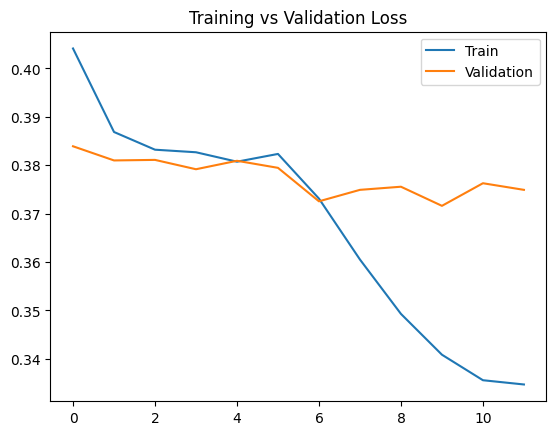

In [ ]:
# ================= TRAIN CURVE =================

plt.figure()

plt.plot(train_hist, label="Train")
plt.plot(val_hist, label="Validation")

plt.legend()
plt.title("Training vs Validation Loss")

plt.show()


In [ ]:
# ================= USER LEVEL METRICS =================

model.load_state_dict(
    torch.load(f"{SAVE_DIR}/model.pt")
)

model.eval()

P = defaultdict(list)
T = {}

with torch.no_grad():

    for ids, mask, y, u in val_loader:

        out = model(
            ids.to(DEVICE),
            mask.to(DEVICE)
        ).cpu()

        for i, uid in enumerate(u):

            P[uid.item()].append(out[i])
            T[uid.item()] = y[i]


X = []
Y = []

for uid in P:

    X.append(torch.stack(P[uid]).mean(0))
    Y.append(T[uid])

X = torch.stack(X).numpy() * trait_stds.values + trait_means.values
Y = torch.stack(Y).numpy() * trait_stds.values + trait_means.values


print("\n=== FINAL DEBERTA METRICS ===")

for i, t in enumerate(TRAITS):

    mae = mean_absolute_error(Y[:, i], X[:, i])
    mse = mean_squared_error(Y[:, i], X[:, i])
    rmse = np.sqrt(mse)
    r = pearsonr(Y[:, i], X[:, i])[0]
    r2 = r2_score(Y[:, i], X[:, i])

    print(
        t,
        "MAE", round(mae, 4),
        "MSE", round(mse, 4),
        "RMSE", round(rmse, 4),
        "R", round(r, 4),
        "R2", round(r2, 4)
    )


print("\nMacro MAE:", mean_absolute_error(Y, X))
print("Macro RMSE:", np.sqrt(mean_squared_error(Y, X)))
print("Macro R2:", r2_score(Y, X))


=== FINAL DEBERTA METRICS ===
openness MAE 20.6392 MSE 598.8885 RMSE 24.4722 R 0.1926 R2 0.0295
conscientiousness MAE 23.4488 MSE 737.9304 RMSE 27.1649 R 0.1837 R2 0.0335
extraversion MAE 21.804 MSE 684.4576 RMSE 26.1621 R 0.2984 R2 0.0481
agreeableness MAE 24.1989 MSE 759.4665 RMSE 27.5584 R 0.2263 R2 0.0353
neuroticism MAE 24.9842 MSE 805.9086 RMSE 28.3885 R 0.2299 R2 0.0454

Macro MAE: 23.01502789653651
Macro RMSE: 26.78302344746569
Macro R2: 0.03837324153261572


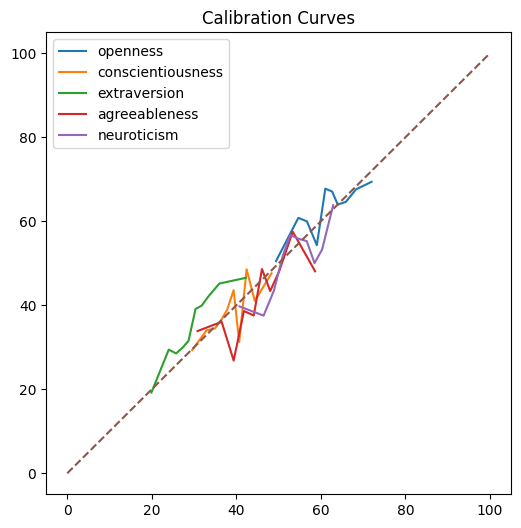

In [ ]:
# ================= CALIBRATION =================

def calibration(y_true, y_pred, bins=10):

    idx = np.argsort(y_pred)

    y_true = y_true[idx]
    y_pred = y_pred[idx]

    step = len(y_true) // bins

    xs = []
    ys = []

    for i in range(bins):

        s = i * step
        e = (i + 1) * step if i < bins - 1 else len(y_true)

        xs.append(y_pred[s:e].mean())
        ys.append(y_true[s:e].mean())

    return xs, ys


plt.figure(figsize=(6, 6))

for i, t in enumerate(TRAITS):

    xs, ys = calibration(Y[:, i], X[:, i])

    plt.plot(xs, ys, label=t)

plt.plot([0, 100], [0, 100], "--")

plt.legend()
plt.title("Calibration Curves")

plt.show()


In [ ]:
# ================= SAVE MODEL =================

tokenizer.save_pretrained(SAVE_DIR)

with open(f"{SAVE_DIR}/norm.json", "w") as f:

    json.dump(
        {
            t: {
                "mean": float(trait_means[t]),
                "std": float(trait_stds[t])
            }
            for t in TRAITS
        },
        f,
        indent=2
    )

print("Model saved to:", SAVE_DIR)

Model saved to: /content/drive/MyDrive/Colab Notebooks/project_one/deberta_personality_model_2
